In [5]:
import pennylane as qml
from opt_pipeline import *
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
[ds] = qml.data.load("ketgpt")

In [3]:
gate_counts, dfs, dfs_runtime = [], [], []
for seed in range(1000):
    # print(seed)
    @qml.qnode(qml.device('default.qubit'))
    def circuit():
        for op in ds.circuits[seed]:
            name = op.name
            params = op.parameters
            wires = op.wires
            if name == 'QubitUnitary':
                continue
            elif name == 'CZ':
                qml.Hadamard(wires[1])
                qml.CNOT(wires)
                qml.Hadamard(wires[1])
            elif name == 'U1':
                qml.RZ(params[0], wires=wires)
            elif name == 'U2':
                qml.RZ(params[0], wires=wires)
                qml.RY(np.pi/2, wires=wires)
                qml.RZ(params[1], wires=wires)
            else:
                qml.apply(op)
        return qml.state()
    try:
        obj = qml.specs(circuit)()['resources']
        df, df_runtime = optimizeCircuit(circuit)
        dfs.append(df)
        dfs_runtime.append(df_runtime)
        gate_counts.append(obj.num_gates)
    except:
        print(f'Failed to process seed={seed}')
        pass

In [6]:
len(gate_counts)

1000

In [8]:
dfs_copy = dfs.copy()
dfs_ratio = []
for idx, df in enumerate(dfs_copy):
    dfs_ratio.append(df.div(df['Original'], axis=0).round(3))
dfs_ratio = [df.drop(columns='Original') for df in dfs_ratio]
dfs_ratio = [df.rename(columns={'Mine': 'This work'}) for df in dfs_ratio]
dfs_ratio[0]

,PennyLane,Qiskit,Tket,This work
Gate count,0.257,0.177,0.251,0.149
Single-qubit gate count,0.173,0.127,0.220,0.087
Two-qubit gate count,0.760,0.480,0.440,0.520
Circuit depth,0.293,0.241,0.259,0.172


In [9]:
records = []
for df in dfs_ratio:
    for metric in df.index:
        for method in df.columns:
            records.append({
                'metric': metric,
                'method': method,
                'ratio': df.loc[metric, method]
            })

long_df = pd.DataFrame(records)

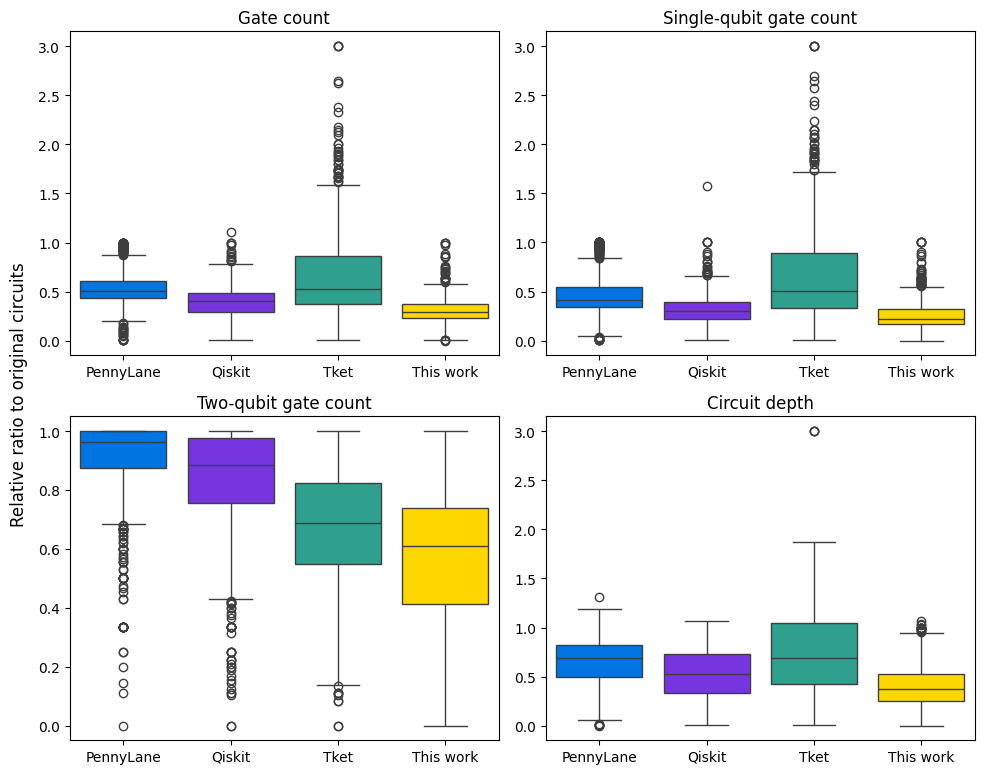

In [10]:
palette={'Qiskit': "#7735E0", 'PennyLane': "#0074E0", 'Tket':'#30A08E', 'This work': "#FFD700"}

# box plots
fig, axes = plt.subplots(2,2, figsize=(10, 8))
for i, metric in enumerate(['Gate count', 'Single-qubit gate count', 'Two-qubit gate count','Circuit depth']):
    ax = axes.flatten()[i]
    subset = long_df[long_df['metric'] == metric]
    sns.boxplot(data=subset, y='ratio', x='method', hue='method', ax=ax, 
                palette=palette,
                saturation=1)
    if i==0:
        ax.set_title('Gate count')
    elif i==1:
        ax.set_title('Single-qubit gate count')
    elif i==2:
        ax.set_title('Two-qubit gate count')
    elif i==3:
        ax.set_title('Circuit depth')
    ax.set_xlabel('')
    ax.set_ylabel('') 
fig.supylabel('Relative ratio to original circuits')
fig.supxlabel('')
plt.tight_layout()
plt.show()

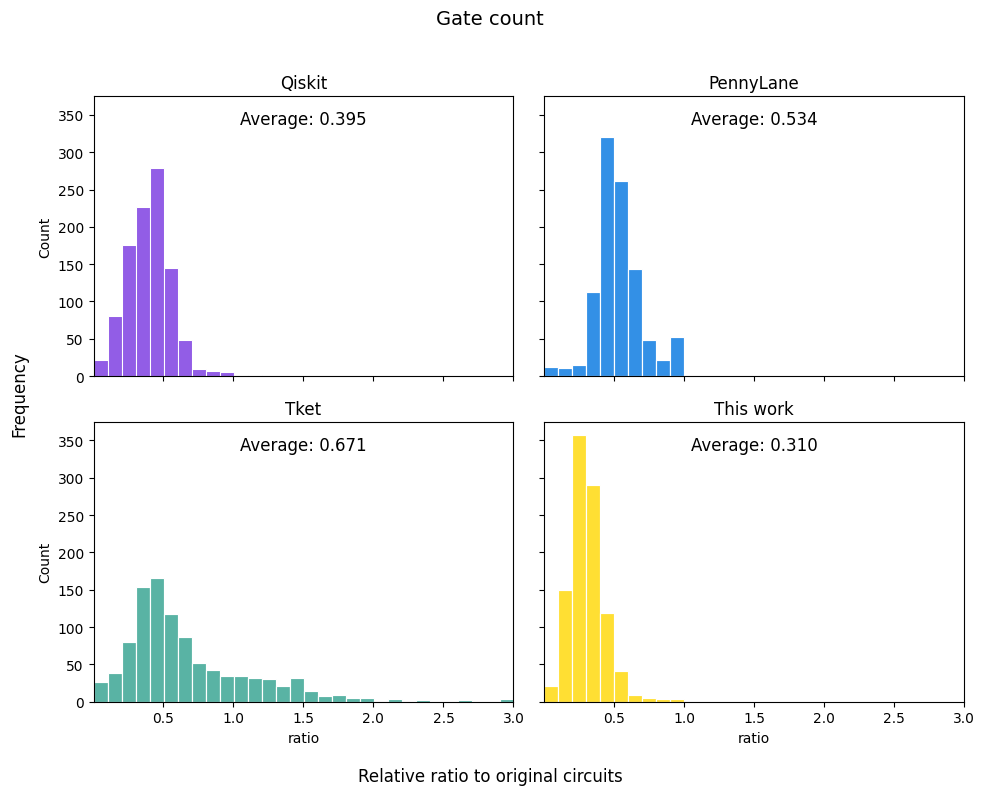

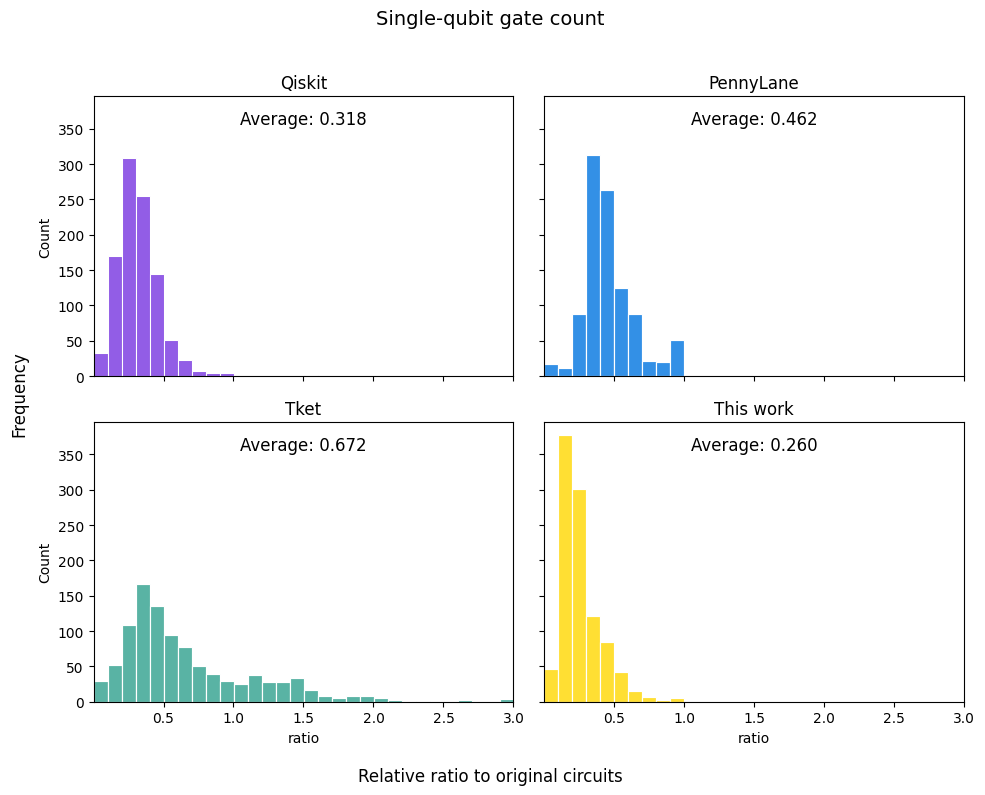

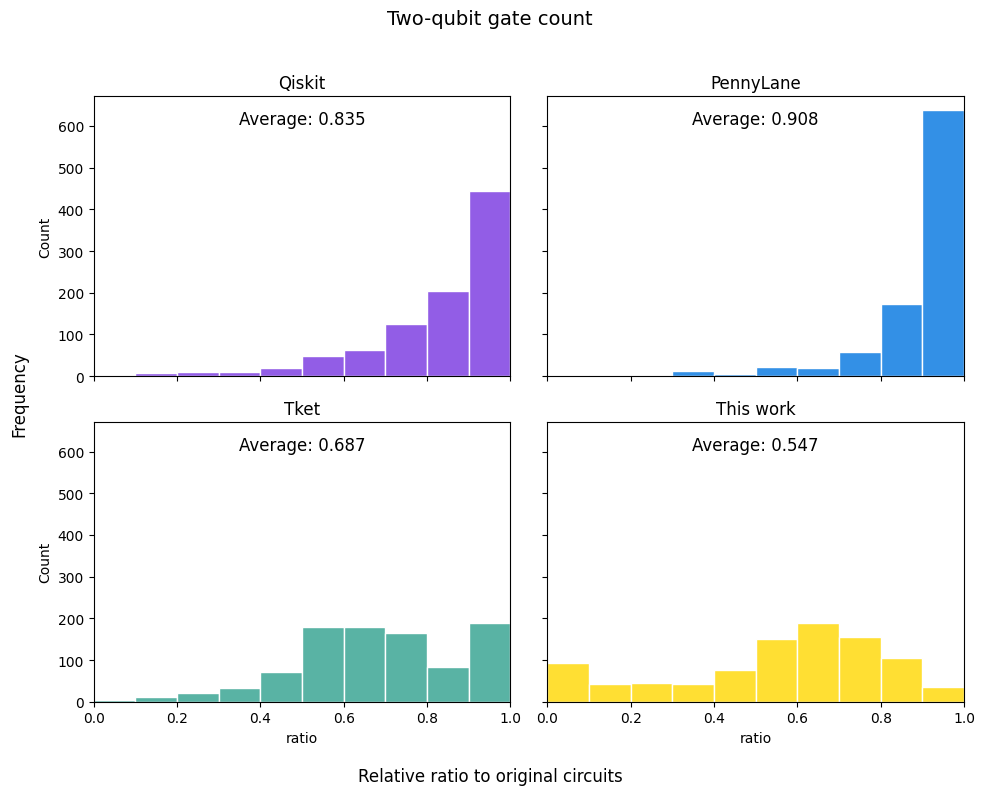

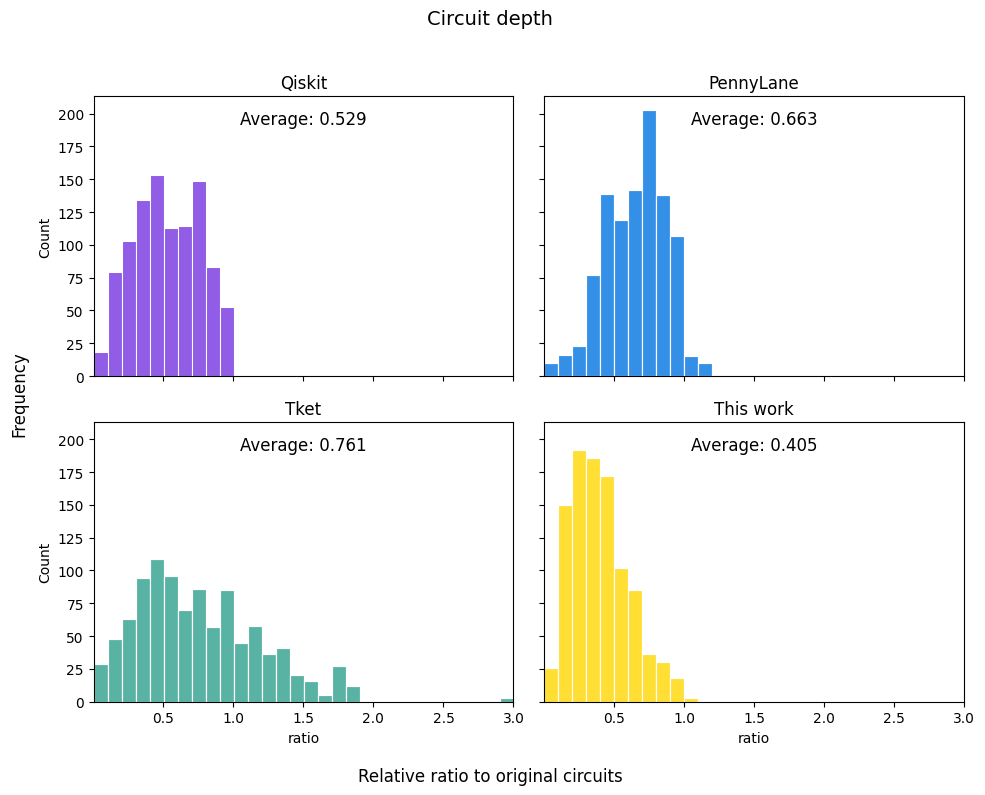

In [27]:
metrics = ['Gate count', 'Single-qubit gate count', 'Two-qubit gate count', 'Circuit depth']

for metric in metrics:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    subset = long_df[long_df['metric'] == metric]

    min_val = subset['ratio'].min()
    max_val = subset['ratio'].max()
    bin_edges = np.arange(min_val, max_val + 0.1, 0.1)

    for i, (method, color) in enumerate(palette.items()):
        ax = axes[i]
        data = subset[subset['method'] == method]

        sns.histplot(
            data=data,
            x='ratio',
            bins=bin_edges,
            ax=ax,
            color=color,
            fill=True,
            alpha=0.8,
            edgecolor='white'
        )
        ax.set_title(method)
        ax.set_xlim(min_val, max_val)

        avg_runtime = data['ratio'].mean()
        ax.text(
            0.5, 0.95,   # center top
            f"Average: {avg_runtime:.3f}",
            ha='center', va='top', fontsize=12,
            transform=ax.transAxes,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
        )

    fig.suptitle(f"{metric}", fontsize=14)
    fig.supxlabel("Relative ratio to original circuits")
    fig.supylabel("Frequency")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


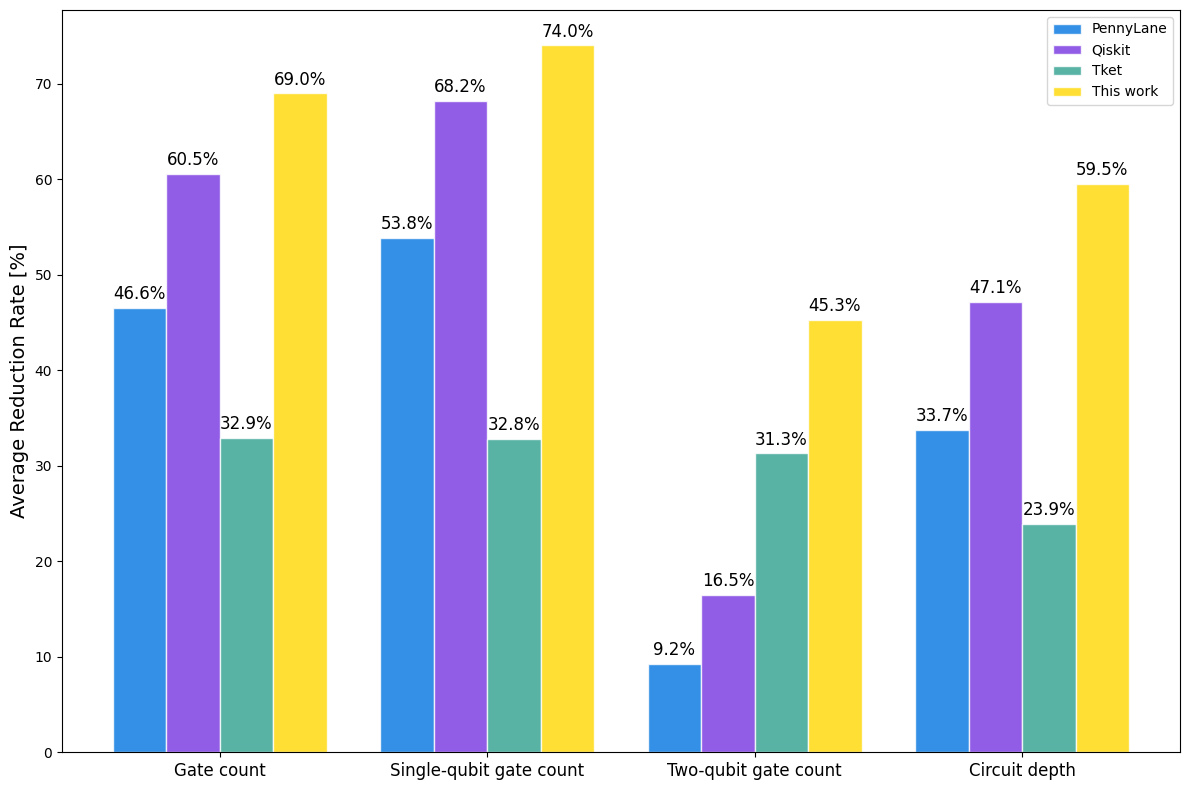

In [28]:
mean_df = long_df.groupby(['method','metric'])['ratio'].agg(['mean','std']).reset_index()
mean_df['mean_percent'] = (1-mean_df['mean'])*100

df_filtered = mean_df[mean_df["metric"] != "gate types"]

methods = ["PennyLane", "Qiskit", "Tket","This work"]

x = np.arange(len(metrics))
bar_width = 0.2

plt.figure(figsize=(12,8))
for i, method in enumerate(methods):
    means = []
    stds = []
    for metric in metrics:
        row = df_filtered[(df_filtered['method'] == method) & (df_filtered['metric'] == metric)]
        means.append(row['mean_percent'].values[0])
        stds.append(row['std'].values[0])
    bars = plt.bar(x + i*bar_width, means,
            width=bar_width, color=palette[method], label=method,
            edgecolor='white', alpha=0.8)

    for bar, val in zip(bars, means):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha='center', va='bottom', fontsize=12)

plt.xticks(x + bar_width*(len(methods)-1)/2, metrics, fontsize=12)
plt.ylabel("Average Reduction Rate [%]", fontsize=14)
plt.xlabel("")
plt.legend()
plt.tight_layout()
plt.show()


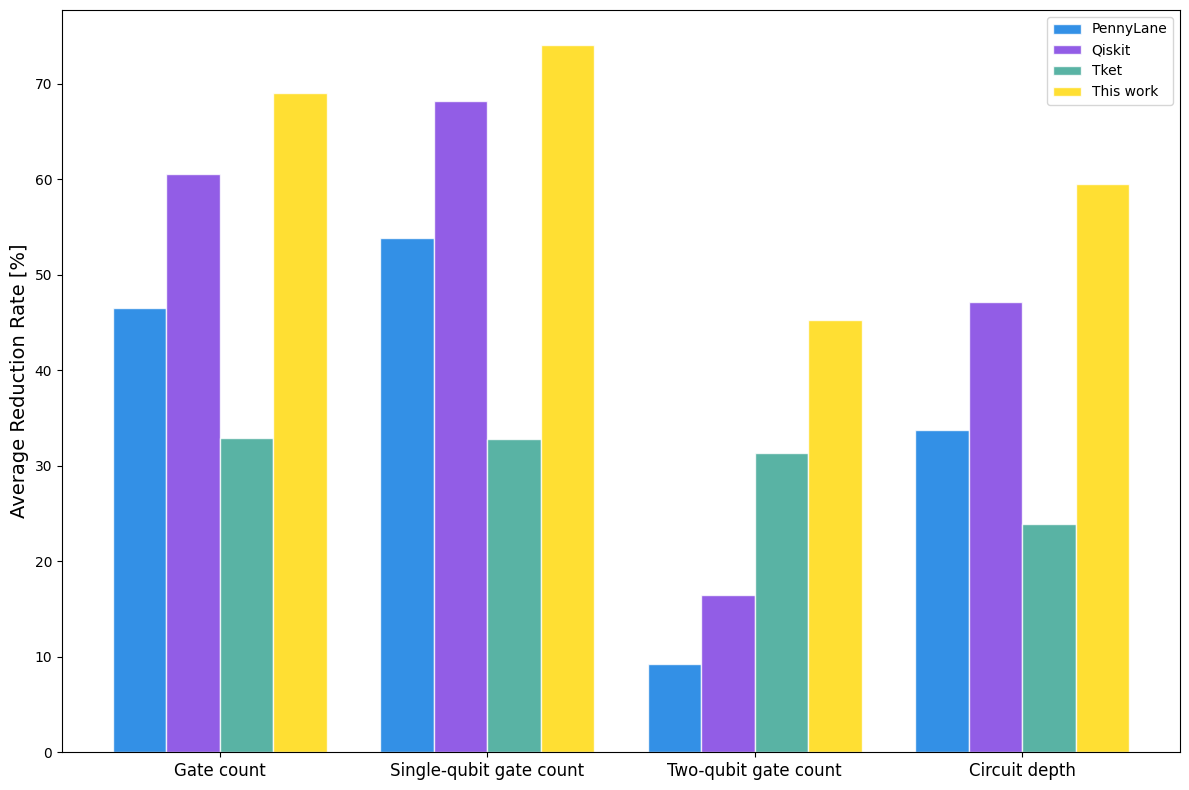

In [29]:
mean_df = long_df.groupby(['method','metric'])['ratio'].agg(['mean','std']).reset_index()
mean_df['mean_percent'] = (1-mean_df['mean'])*100
df_filtered = mean_df[mean_df["metric"] != "gate types"]

x = np.arange(len(metrics))
bar_width = 0.2

plt.figure(figsize=(12,8))
for i, method in enumerate(methods):
    means = []
    stds = []
    for metric in metrics:
        row = df_filtered[(df_filtered['method'] == method) & (df_filtered['metric'] == metric)]
        means.append(row['mean_percent'].values[0])
        stds.append(row['std'].values[0])
    bars = plt.bar(x + i*bar_width, means,
            width=bar_width, color=palette[method], label=method,
            edgecolor='white', alpha=0.8)

    # for bar, val in zip(bars, means):
    #     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
    #              f"{val:.1f}%", ha='center', va='bottom', fontsize=12)

plt.xticks(x + bar_width*(len(methods)-1)/2, metrics, fontsize=12)
plt.ylabel("Average Reduction Rate [%]", fontsize=14)
plt.xlabel("")
plt.legend()
plt.tight_layout()
plt.show()


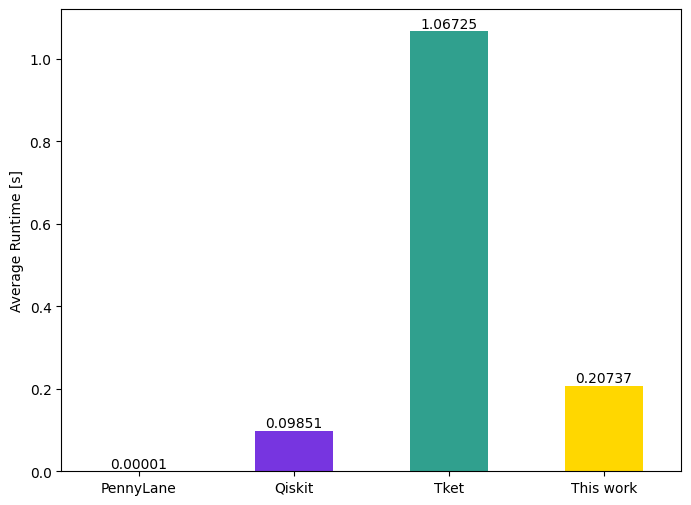

In [30]:
all_dfs = pd.concat(dfs_runtime, ignore_index=True)
avg_runtime = all_dfs.mean()

plt.figure(figsize=(8,6))
bars = avg_runtime.plot(kind="bar", color=[palette[col] for col in avg_runtime.index])
plt.ylabel("Average Runtime [s]")
plt.xticks(rotation=0)

for i, val in enumerate(avg_runtime):
    plt.text(i, val + (val*0.001), f"{val:.5f}", ha='center', va='bottom', fontsize=10)
plt.show()

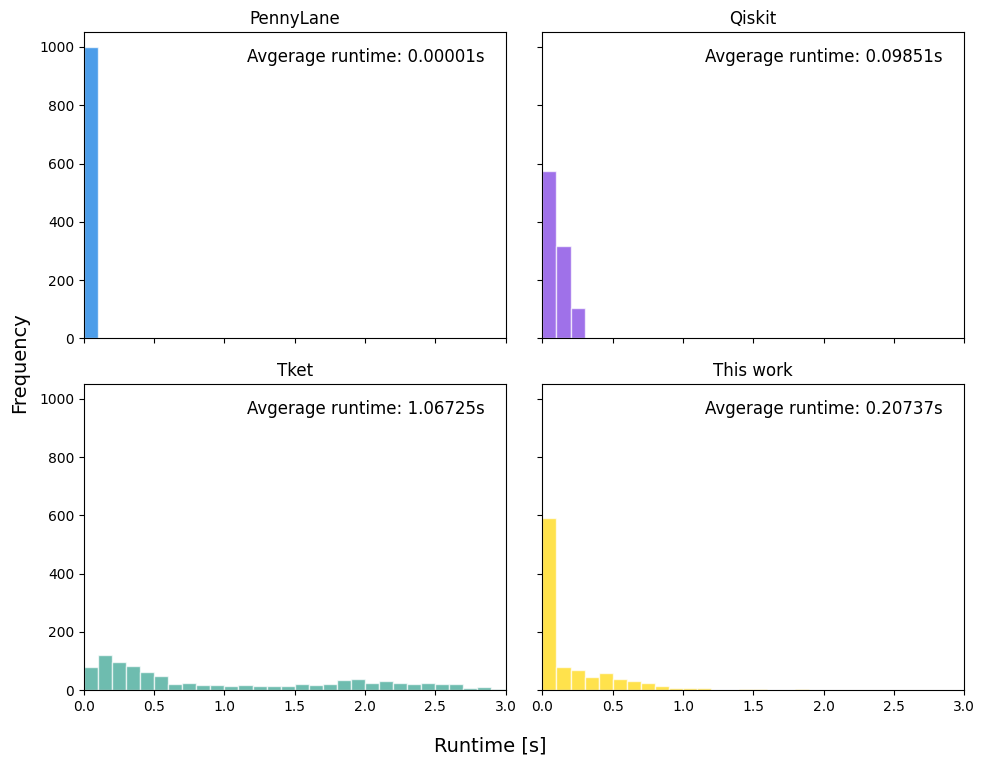

In [31]:
min_val = all_dfs.min().min()
max_val = all_dfs.max().max()
bin_edges = np.arange(min_val, max_val + 0.1, 0.1)  

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()
for i, col in enumerate(all_dfs.columns):
    axes[i].hist(all_dfs[col], bins=bin_edges,
                 color=palette[col], alpha=0.7, edgecolor='white')
    axes[i].set_title(col)
    avg_runtime = all_dfs[col].mean() # present averages
    axes[i].text(0.95, 0.95,
                 f"Avgerage runtime: {avg_runtime:.5f}s",
                 ha='right', va='top', fontsize=12,
                 transform=axes[i].transAxes,   # <-- key line
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
for ax in axes:
    ax.set_xlim(0, 3.0)
    ax.set_ylim(0, max([a.get_ylim()[1] for a in axes]))

fig.supxlabel("Runtime [s]", fontsize=14)
fig.supylabel("Frequency", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

c:\Users\syj43\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


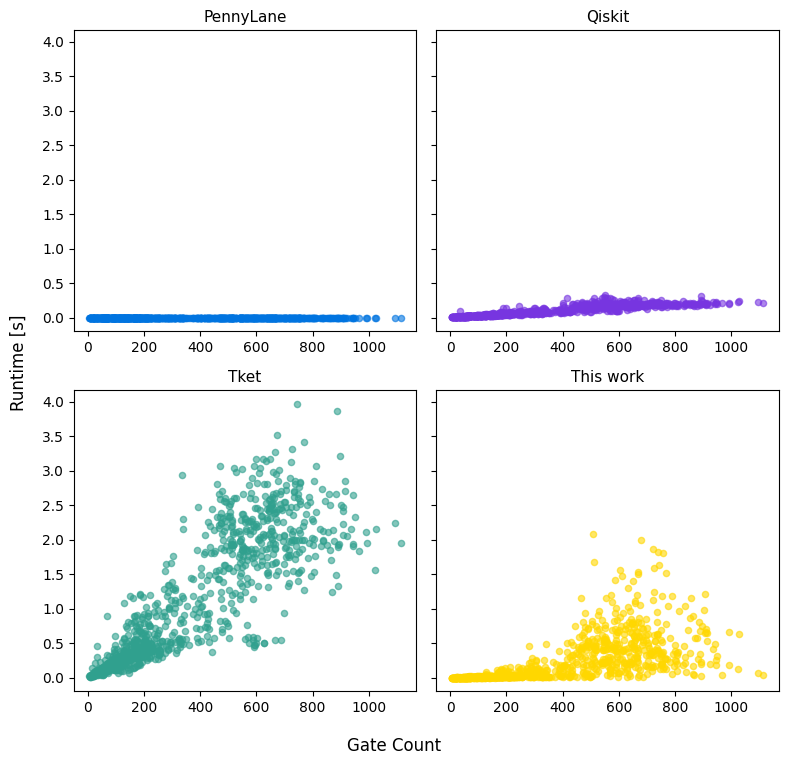

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharey=True)
axes = axes.flatten()

for i, col in enumerate(methods):
    ax = axes[i]
    x_vals = [gate_counts[j] for j in range(len(gate_counts))]
    y_vals = [dfs_runtime[j][col] for j in range(len(gate_counts))]
    ax.scatter(x_vals, y_vals,
               color=palette[col], alpha=0.6, s=20)
    ax.set_title(col, fontsize=11)

fig.supxlabel("Gate Count", fontsize=12)
fig.supylabel("Runtime [s]", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()